<a href="https://colab.research.google.com/github/Shraddha-Bankar/Responsible_AI_Fairness_and_Explainability_Analysis_In_Loan_Prediction_System/blob/main/Ioan_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/test_Y3wMUE5_7gLdaTN.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [ ]:
# Display basic information about the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


None

In [ ]:
# Display descriptive statistics for numerical columns
display(df.describe())

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [ ]:
# Check for missing values
display(df.isnull().sum())

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


In [ ]:
# Impute missing values for categorical features with the mode
for col in ['Gender', 'Dependents', 'Self_Employed', 'Credit_History']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Impute missing values for numerical features with the median
for col in ['LoanAmount', 'Loan_Amount_Term']:
    df[col] = df[col].fillna(df[col].median())

# Verify that there are no more missing values
display(df.isnull().sum())

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
# Drop Loan_ID as it is an identifier and not a feature
df_processed = df.drop('Loan_ID', axis=1)

# Identify categorical columns for one-hot encoding
categorical_cols = df_processed.select_dtypes(include='object').columns

# Apply one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

display(df_processed.head())

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5720,0,110.0,360.0,1.0,True,True,False,False,False,False,False,False,True
1,3076,1500,126.0,360.0,1.0,True,True,True,False,False,False,False,False,True
2,5000,1800,208.0,360.0,1.0,True,True,False,True,False,False,False,False,True
3,2340,2546,100.0,360.0,1.0,True,True,False,True,False,False,False,False,True
4,3276,0,78.0,360.0,1.0,True,False,False,False,False,True,False,False,True


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid') # Set a nice style for plots

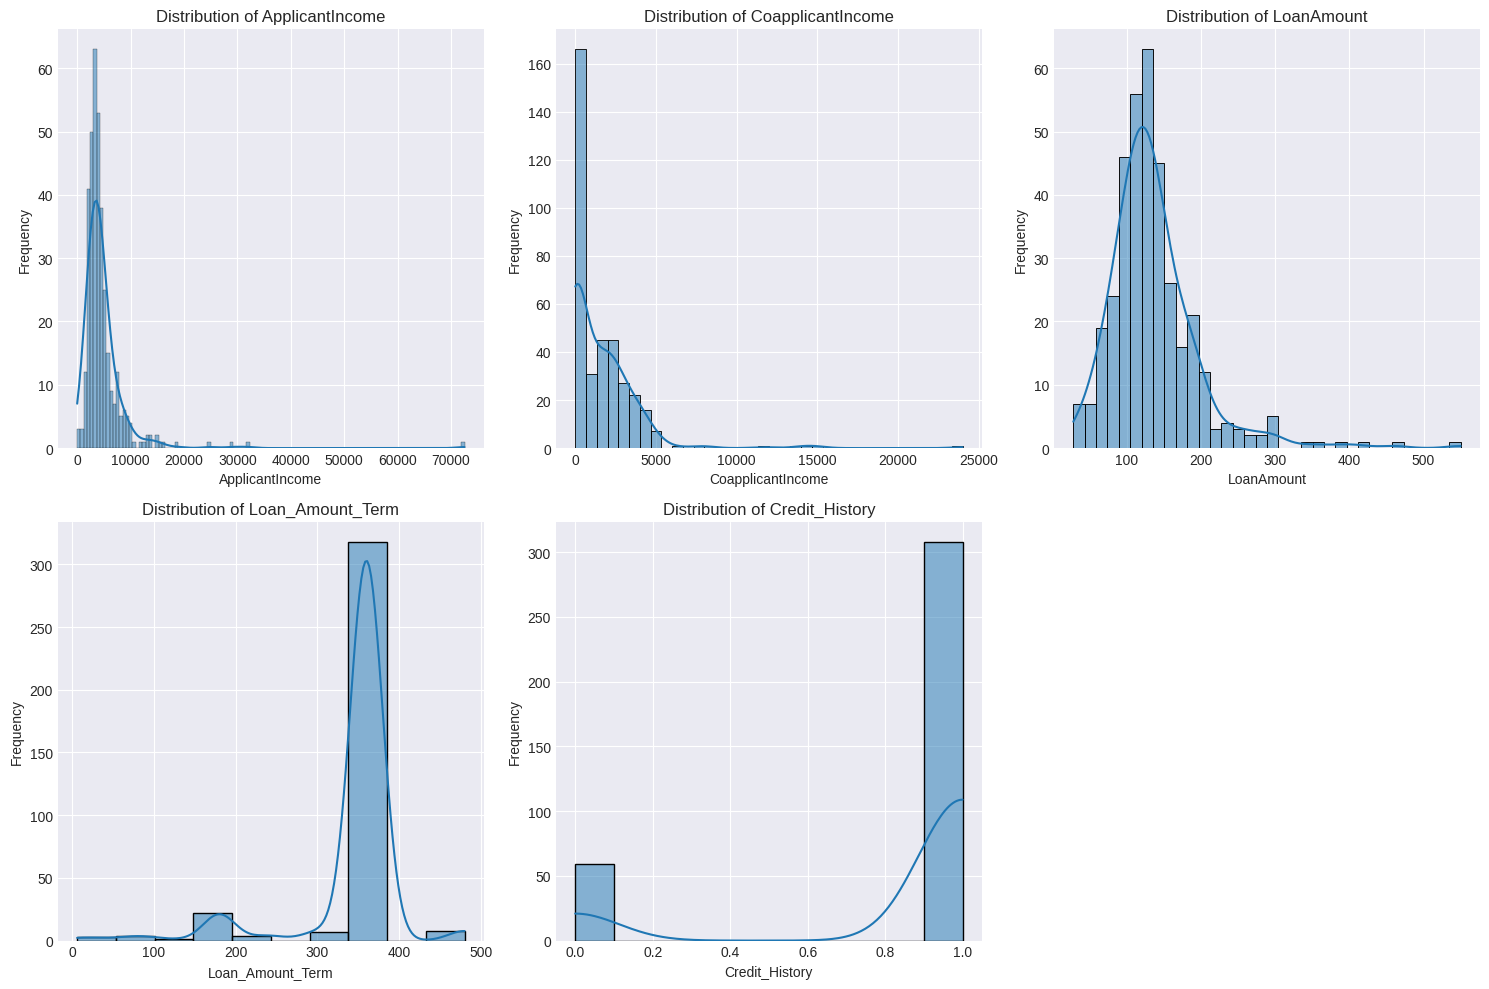

In [ ]:
numerical_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i) # Adjust grid size as needed
    sns.histplot(df_processed[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

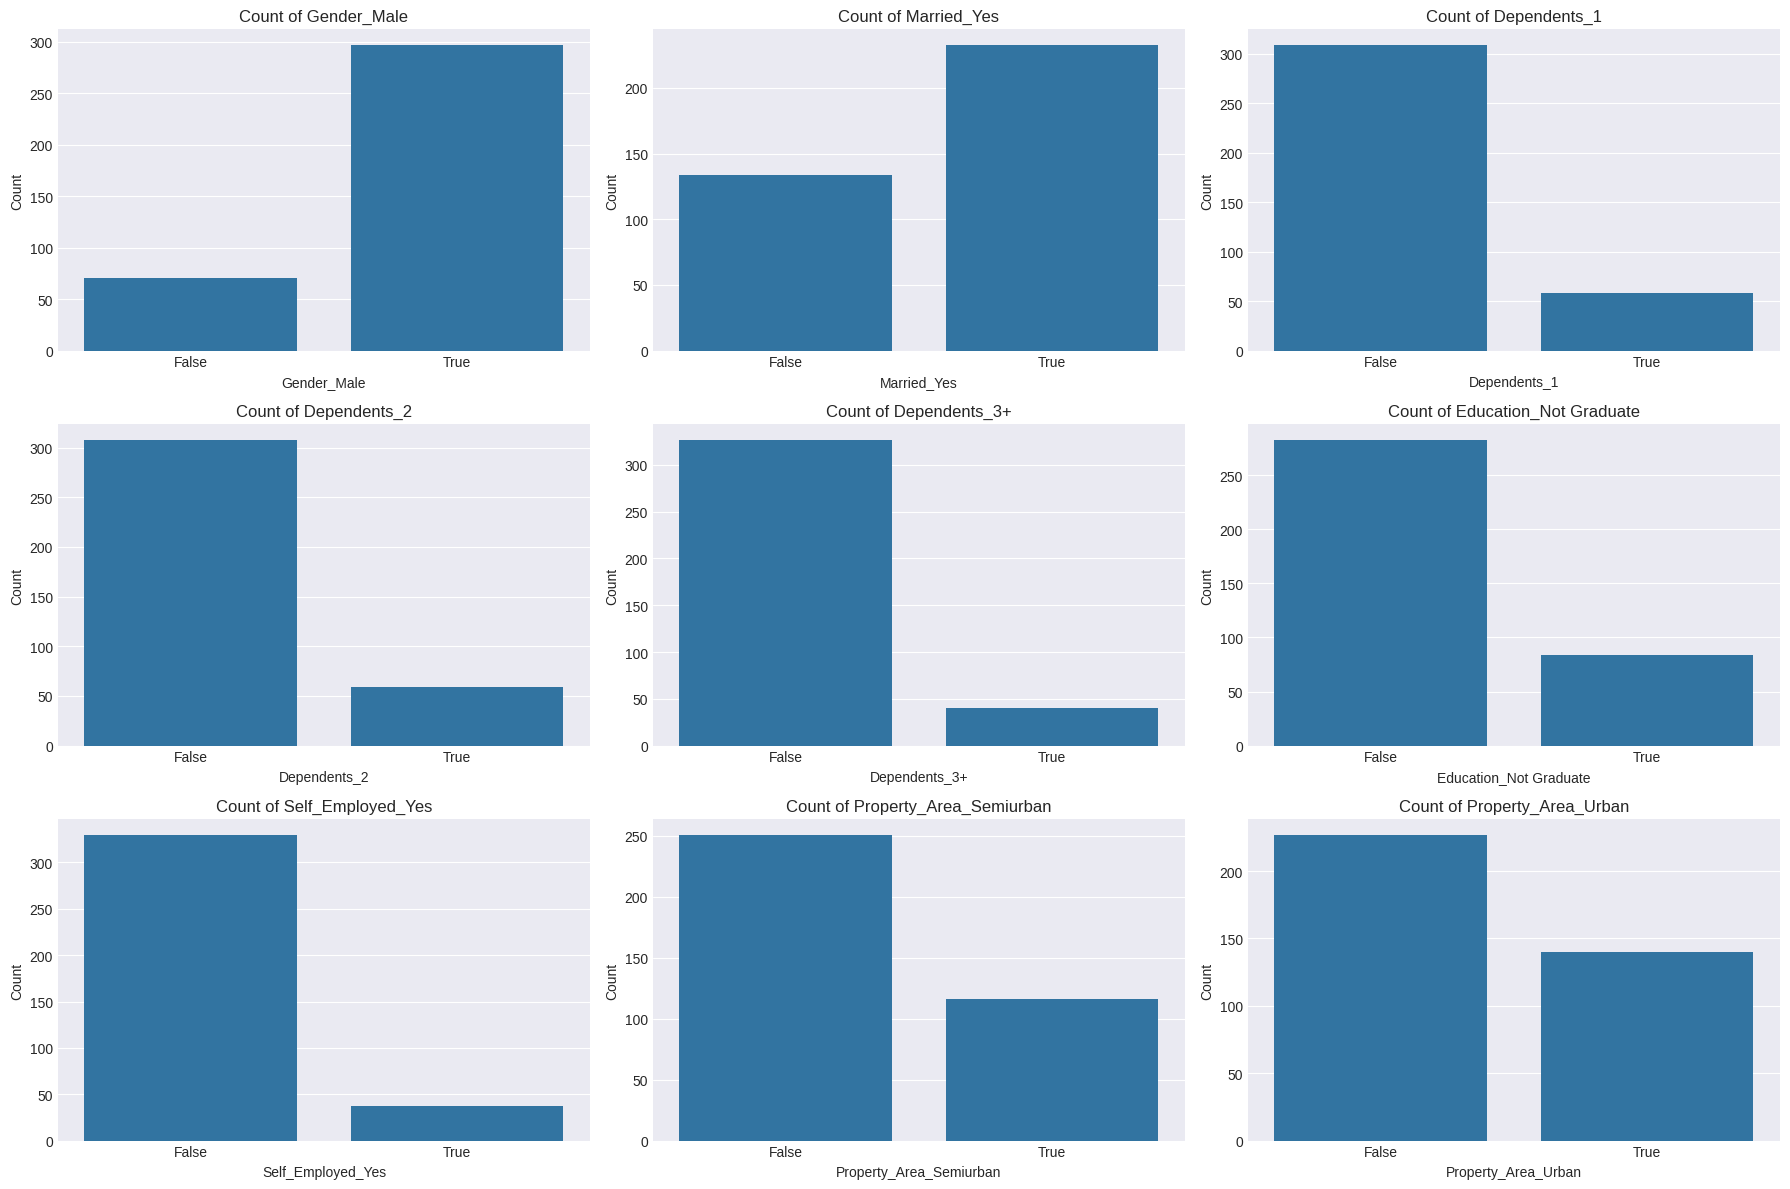

In [ ]:
categorical_features_encoded = ['Gender_Male', 'Married_Yes', 'Dependents_1', 'Dependents_2', 'Dependents_3+',
                              'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(categorical_features_encoded, 1):
    plt.subplot(3, 3, i) # Adjust grid size as needed
    sns.countplot(x=df_processed[feature])
    plt.title(f'Count of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

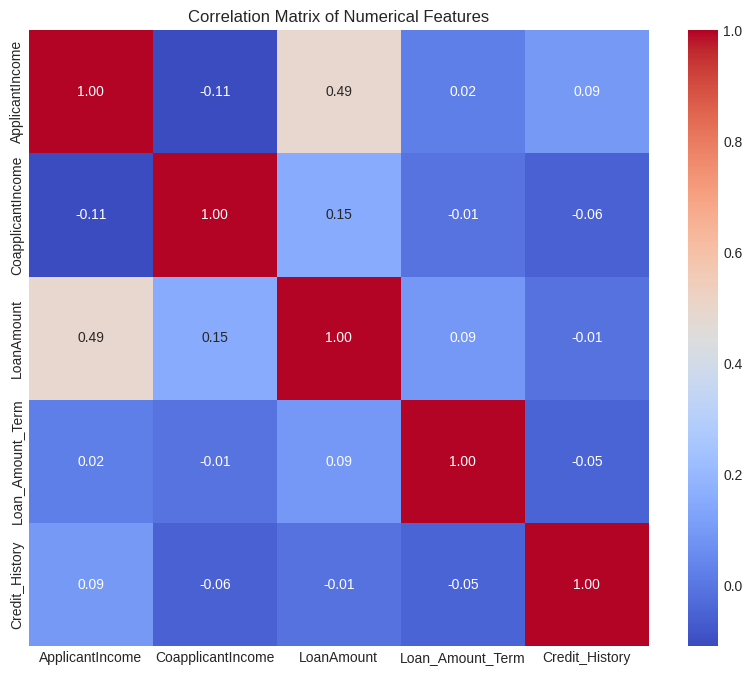

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_processed[numerical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
# Create a synthetic target variable 'Loan_Status' based on 'Credit_History'
# Assuming Credit_History = 1 means Approved (1), and 0 means Rejected (0)
df_processed['Loan_Status'] = df_processed['Credit_History'].astype(int)

# Display the count of each status to understand our synthetic target distribution
display(df_processed['Loan_Status'].value_counts())

,count
Loan_Status,
1,308
0,59


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_processed.drop('Loan_Status', axis=1)
y = df_processed['Loan_Status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (293, 14)
X_test shape: (74, 14)
y_train shape: (293,)
y_test shape: (74,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        62

    accuracy                           1.00        74
   macro avg       1.00      1.00      1.00        74
weighted avg       1.00      1.00      1.00        74



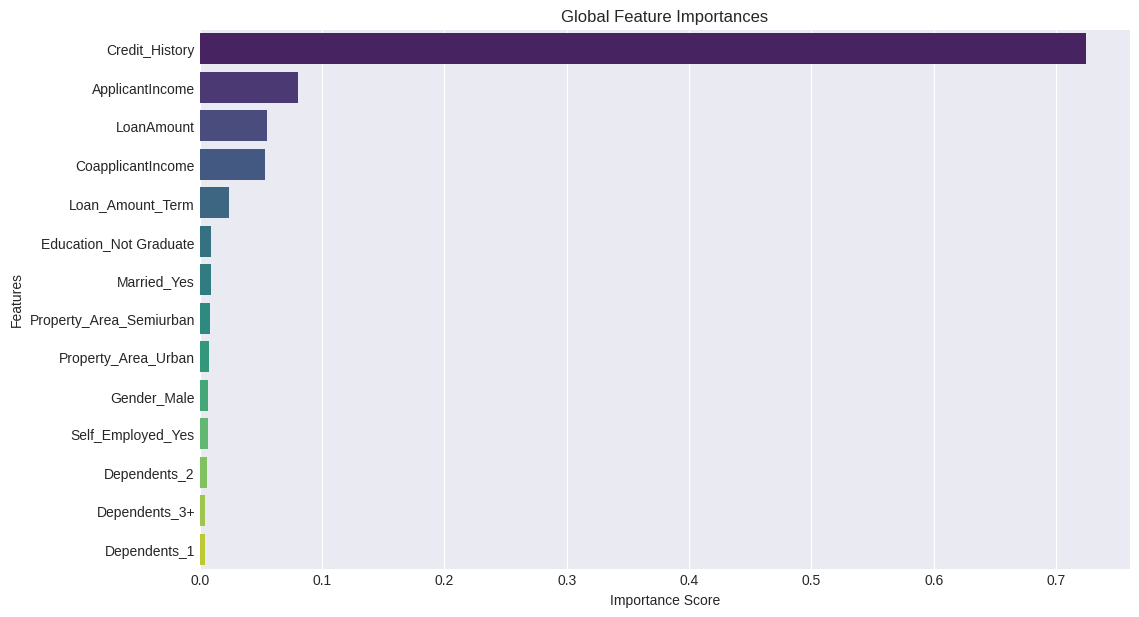

In [ ]:
# Get feature importances from the trained model
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)

# Sort feature importances in descending order
feature_importances = feature_importances.sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.values, y=feature_importances.index, hue=feature_importances.index, palette='viridis', legend=False)
plt.title('Global Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [ ]:
# Install SHAP library if not already installed
!pip install shap

import shap

# Create a SHAP explainer object
# For tree-based models like RandomForestClassifier, TreeExplainer is efficient
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
# This might take a moment depending on the size of X_test
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")
print(f"Shape of SHAP values (for class 0 and 1): {len(shap_values)}, {shap_values[0].shape}")

SHAP values calculated successfully!
Shape of SHAP values (for class 0 and 1): 74, (14, 2)


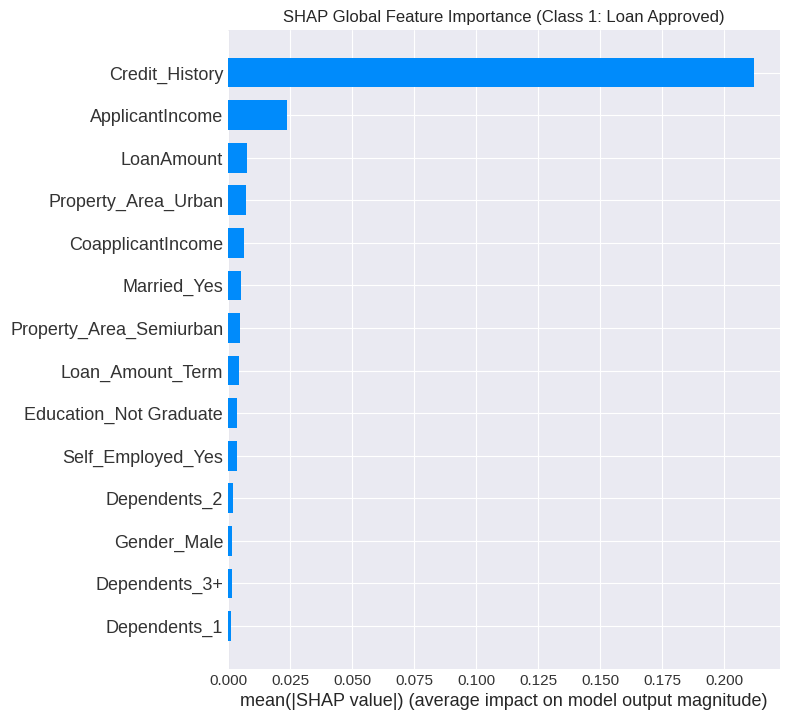

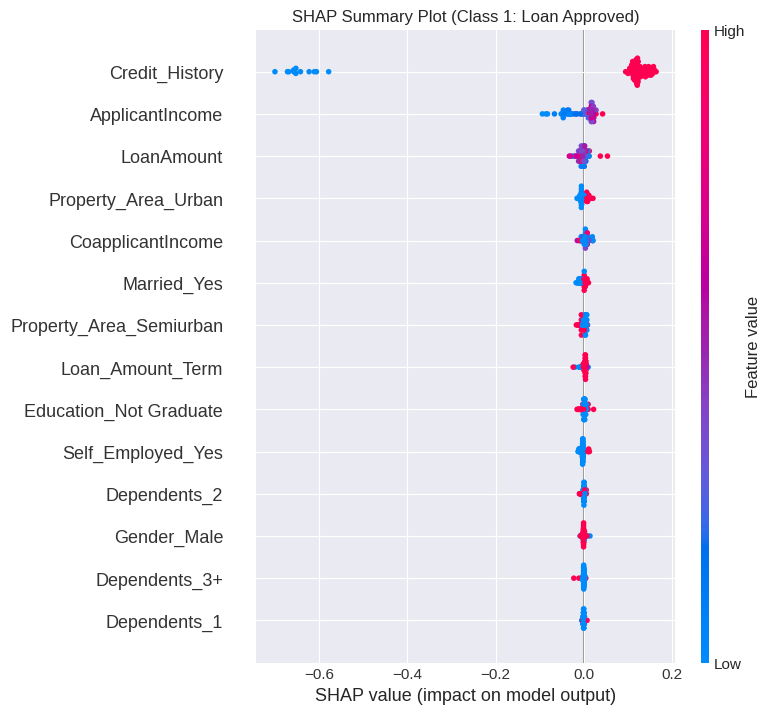

In [ ]:
# Generate SHAP summary plot for the first class (class 0, if binary classification)
# Assuming a binary classification where shap_values is a list of two arrays (for class 0 and class 1)
# We'll visualize for the positive class (class 1, Loan Approved)

# Force plot for the entire dataset
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", show=False)
plt.title('SHAP Global Feature Importance (Class 1: Loan Approved)')
plt.show()

# Summary plot for feature impact and direction
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
plt.title('SHAP Summary Plot (Class 1: Loan Approved)')
plt.show()

Explaining prediction for instance 0 from the test set...
Actual target value: 1
Model's predicted probability (class 1): 0.9800


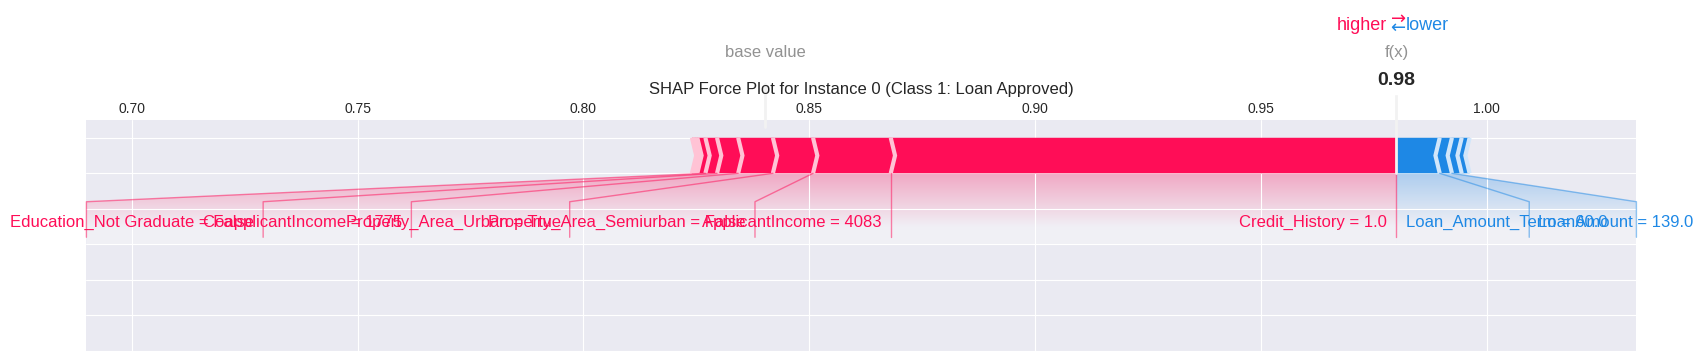

In [ ]:
# Select a single instance from the test set for local explanation
instance_idx = 0 # You can change this index to explore different instances
single_instance = X_test.iloc[[instance_idx]]

# Get the SHAP values for this single instance
single_instance_shap_values = explainer.shap_values(single_instance)

print(f"Explaining prediction for instance {instance_idx} from the test set...")
print(f"Actual target value: {y_test.iloc[instance_idx]}")
print(f"Model's predicted probability (class 1): {model.predict_proba(single_instance)[0,1]:.4f}")

# Visualize the force plot for the positive class (class 1)
shap.force_plot(explainer.expected_value[1], single_instance_shap_values[0, :, 1], single_instance, matplotlib=True, show=False)
plt.title(f'SHAP Force Plot for Instance {instance_idx} (Class 1: Loan Approved)')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

def calculate_fairness_metrics(y_true, y_pred, sensitive_attribute, group_name):
    # Ensure confusion_matrix always returns a 2x2 matrix for labels [0, 1]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # Handle cases where denominator might be zero for TPR or FPR
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0 # True Positive Rate (Recall)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0 # False Positive Rate

    print(f"Group: {group_name} (n={len(y_true)})")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  True Positive Rate (Recall): {tpr:.4f}")
    print(f"  False Positive Rate: {fpr:.4f}")
    print("\n")

    return {'group': group_name, 'accuracy': accuracy, 'tpr': tpr, 'fpr': fpr}

fairness_results = []

# Get predictions for the entire test set
y_pred_test = model.predict(X_test)

# Analyze 'Gender'
print("##### Analyzing Fairness by Gender #####\n")
for gender_val in ['Gender_Male_0', 'Gender_Male_1']:
    if gender_val == 'Gender_Male_0': # Female
        group_mask = (X_test['Gender_Male'] == 0)
        group_name = 'Female'
    else: # Male
        group_mask = (X_test['Gender_Male'] == 1)
        group_name = 'Male'

    if group_mask.any(): # Ensure the group exists in the test set
        fairness_results.append(calculate_fairness_metrics(y_test[group_mask], y_pred_test[group_mask.values], 'Gender', group_name))
    else:
        print(f"No instances for group: {group_name} in test set.\n")

# Analyze 'Married'
print("##### Analyzing Fairness by Marital Status #####\n")
for married_val in ['Married_Yes_0', 'Married_Yes_1']:
    if married_val == 'Married_Yes_0': # Not Married
        group_mask = (X_test['Married_Yes'] == 0)
        group_name = 'Not Married'
    else: # Married
        group_mask = (X_test['Married_Yes'] == 1)
        group_name = 'Married'

    if group_mask.any():
        fairness_results.append(calculate_fairness_metrics(y_test[group_mask], y_pred_test[group_mask.values], 'Married', group_name))
    else:
        print(f"No instances for group: {group_name} in test set.\n")

# Analyze 'Education'
print("##### Analyzing Fairness by Education #####\n")
for edu_val in ['Education_Not Graduate_0', 'Education_Not Graduate_1']:
    if edu_val == 'Education_Not Graduate_0': # Graduate
        group_mask = (X_test['Education_Not Graduate'] == 0)
        group_name = 'Graduate'
    else: # Not Graduate
        group_mask = (X_test['Education_Not Graduate'] == 1)
        group_name = 'Not Graduate'

    if group_mask.any():
        fairness_results.append(calculate_fairness_metrics(y_test[group_mask], y_pred_test[group_mask.values], 'Education', group_name))
    else:
        print(f"No instances for group: {group_name} in test set.\n")

# Analyze 'Self_Employed'
print("##### Analyzing Fairness by Self-Employment Status #####\n")
for se_val in ['Self_Employed_Yes_0', 'Self_Employed_Yes_1']:
    if se_val == 'Self_Employed_Yes_0': # Not Self-Employed
        group_mask = (X_test['Self_Employed_Yes'] == 0)
        group_name = 'Not Self-Employed'
    else: # Self-Employed
        group_mask = (X_test['Self_Employed_Yes'] == 1)
        group_name = 'Self-Employed'

    if group_mask.any():
        fairness_results.append(calculate_fairness_metrics(y_test[group_mask], y_pred_test[group_mask.values], 'Self_Employed', group_name))
    else:
        print(f"No instances for group: {group_name} in test set.\n")

# Analyze 'Property_Area'
print("##### Analyzing Fairness by Property Area #####\n")
for pa_val in ['Property_Area_Semiurban_0', 'Property_Area_Semiurban_1', 'Property_Area_Urban_0', 'Property_Area_Urban_1']:
    # Construct the group mask based on one-hot encoded columns for Property_Area
    if pa_val == 'Property_Area_Semiurban_0' and 'Property_Area_Semiurban' in X_test.columns and 'Property_Area_Urban' in X_test.columns: # Rural (neither semiurban nor urban)
        group_mask = (X_test['Property_Area_Semiurban'] == 0) & (X_test['Property_Area_Urban'] == 0)
        group_name = 'Rural'
    elif pa_val == 'Property_Area_Semiurban_1' and 'Property_Area_Semiurban' in X_test.columns: # Semiurban
        group_mask = (X_test['Property_Area_Semiurban'] == 1)
        group_name = 'Semiurban'
    elif pa_val == 'Property_Area_Urban_1' and 'Property_Area_Urban' in X_test.columns: # Urban
        group_mask = (X_test['Property_Area_Urban'] == 1)
        group_name = 'Urban'
    else:
        continue # Skip combinations that don't represent a clear group or columns are missing

    if group_mask.any():
        fairness_results.append(calculate_fairness_metrics(y_test[group_mask], y_pred_test[group_mask.values], 'Property_Area', group_name))
    else:
        print(f"No instances for group: {group_name} in test set.\n")

# Display overall fairness results in a DataFrame
fairness_df = pd.DataFrame(fairness_results)
display(fairness_df)

##### Analyzing Fairness by Gender #####

Group: Female (n=14)
  Accuracy: 1.0000
  True Positive Rate (Recall): 1.0000
  False Positive Rate: 0.0000


Group: Male (n=60)
  Accuracy: 1.0000
  True Positive Rate (Recall): 1.0000
  False Positive Rate: 0.0000


##### Analyzing Fairness by Marital Status #####

Group: Not Married (n=29)
  Accuracy: 1.0000
  True Positive Rate (Recall): 1.0000
  False Positive Rate: 0.0000


Group: Married (n=45)
  Accuracy: 1.0000
  True Positive Rate (Recall): 1.0000
  False Positive Rate: 0.0000


##### Analyzing Fairness by Education #####

Group: Graduate (n=53)
  Accuracy: 1.0000
  True Positive Rate (Recall): 1.0000
  False Positive Rate: 0.0000


Group: Not Graduate (n=21)
  Accuracy: 1.0000
  True Positive Rate (Recall): 1.0000
  False Positive Rate: 0.0000


##### Analyzing Fairness by Self-Employment Status #####

Group: Not Self-Employed (n=70)
  Accuracy: 1.0000
  True Positive Rate (Recall): 1.0000
  False Positive Rate: 0.0000


Group: Self-

,group,accuracy,tpr,fpr
0,Female,1.0,1.0,0.0
1,Male,1.0,1.0,0.0
2,Not Married,1.0,1.0,0.0
3,Married,1.0,1.0,0.0
4,Graduate,1.0,1.0,0.0
5,Not Graduate,1.0,1.0,0.0
6,Not Self-Employed,1.0,1.0,0.0
7,Self-Employed,1.0,1.0,0.0
8,Rural,1.0,1.0,0.0
9,Semiurban,1.0,1.0,0.0
